In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

from IPython.display import Latex

# ВАХ образца

Измеряем ВАХ от -1 А до +1 А.

V [мВ]

I [А]

In [54]:
data_vah = pd.read_csv("data_vah.csv", dtype=np.float128)
data_vah

,V,I
0,-0.134,-1.0
1,-0.120,-0.9
2,-0.106,-0.8
3,-0.093,-0.7
4,-0.079,-0.6
5,-0.065,-0.5
6,-0.051,-0.4
7,-0.038,-0.3
8,-0.024,-0.2
9,-0.010,-0.1


In [55]:
def linear(x, k, b):
    return k*x + b

$$ U(I) = U_0 + R \cdot I $$

R = (0.0001376 +- 0.0000005) Ом
U_0 = (0.0000033 +- 0.0000003) В


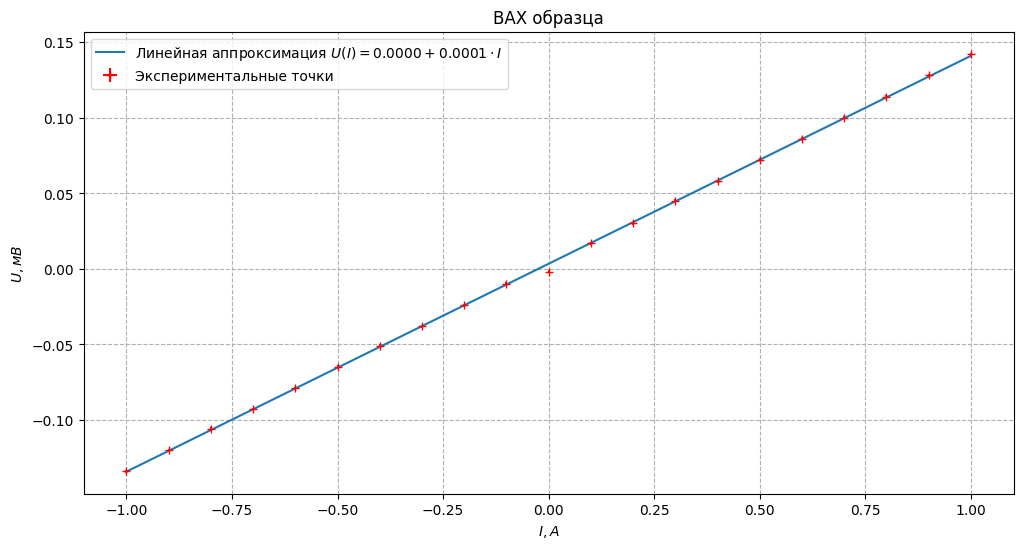

In [56]:
plt.figure(figsize=(12, 6))
plt.title(r"ВАХ образца")
plt.grid(True, linestyle="--")

# SI
x = data_vah["I"]
y = data_vah["V"] / 1e3

plt.errorbar(x=x, xerr=0.001, y=y * 1e3, yerr=0.001, fmt="+r", label="Экспериментальные точки")


popt, pcov = curve_fit(linear, xdata=x, ydata=y, sigma=0.001)


R, U_0 = popt
R = np.float128(R)
U_0 = np.float128(U_0)

sigma_R, sigma_U_0 = np.sqrt(np.diag(pcov), dtype=np.float128)


print(f"R = ({R:.7f} +- {sigma_R:.7f}) Ом")
print(f"U_0 = ({U_0:.7f} +- {sigma_U_0:.7f}) В")

x_model = np.linspace(min(x), max(x), 1000)
y_model = R * x_model + U_0



plt.plot(x_model, y_model * 1e3, label=rf"Линейная аппроксимация $U(I) = {U_0:.4f} + {R:.4f} \cdot I$")



plt.ylabel(r"$U, мВ$")
plt.xlabel(r"$I, А$")

plt.legend()
plt.show()

# Измерение теплопроводности

Измерение температурное

Термопара образец: V [мВ]

Напряжение нагревателя: U_N [В]

Ток через образец: I_N [А]

Время установления равновесия: t [с]

Ток через нагреватель экрана: I_E [А]

Напряжение на термопаре экран-образец: Delta_V [мВ]

In [57]:
data_thermo = pd.read_csv("data_thermo.csv", dtype=np.float128)
data_thermo

,V,U_N,I_N,t,I_E,Delta_V
0,0.310,2.6040,0.203,300.0,0.458,-0.002
1,0.501,3.2300,0.250,300.0,0.565,-0.001
2,0.277,2.2530,0.175,720.0,0.394,0.005
3,0.199,1.9541,0.150,600.0,0.353,0.002
4,0.136,1.6012,0.125,720.0,0.297,0.000
5,0.088,1.2855,0.100,780.0,0.235,0.006
6,0.054,0.9638,0.075,600.0,0.185,0.004
7,0.389,2.8820,0.225,780.0,0.528,-0.011


In [58]:
data_thermo_drop = pd.read_csv("data_thermo_drop.csv", dtype=np.float128)
data_thermo_drop

,V,U_N,I_N,t,I_E,Delta_V
0,0.477,3.857,0.3,150.0,0.678,0.025


In [59]:
k = np.float128('43e-3') # мВ / К

In [60]:
data_thermo_drop["P_N"] = data_thermo_drop["U_N"] * data_thermo_drop["I_N"]

data_thermo_drop["Delta_T"] = data_thermo_drop["V"] / k
data_thermo_drop

,V,U_N,I_N,t,I_E,Delta_V,P_N,Delta_T
0,0.477,3.857,0.3,150.0,0.678,0.025,1.1571,11.093023


In [61]:
data_thermo["P_N"] = data_thermo["U_N"] * data_thermo["I_N"]

data_thermo["Delta_T"] = data_thermo["V"] / k
data_thermo

,V,U_N,I_N,t,I_E,Delta_V,P_N,Delta_T
0,0.310,2.6040,0.203,300.0,0.458,-0.002,0.528612,7.209302
1,0.501,3.2300,0.250,300.0,0.565,-0.001,0.807500,11.651163
2,0.277,2.2530,0.175,720.0,0.394,0.005,0.394275,6.441860
3,0.199,1.9541,0.150,600.0,0.353,0.002,0.293115,4.627907
4,0.136,1.6012,0.125,720.0,0.297,0.000,0.200150,3.162791
5,0.088,1.2855,0.100,780.0,0.235,0.006,0.128550,2.046512
6,0.054,0.9638,0.075,600.0,0.185,0.004,0.072285,1.255814
7,0.389,2.8820,0.225,780.0,0.528,-0.011,0.648450,9.046512


$$ \Delta T = A \cdot P + T_\varepsilon $$

A = (14 +- 1) К / Вт
epsilon = (0.4104 +- 0.2354) К


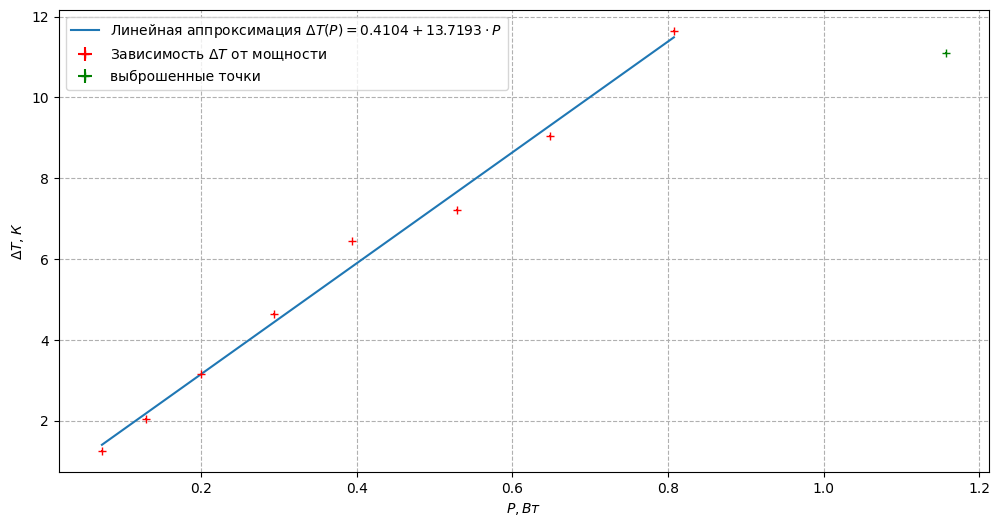

In [62]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")

plt.errorbar(x=data_thermo["P_N"], xerr=0.001, y=data_thermo["Delta_T"], yerr=0.001, fmt="+r", label=r"Зависимость $\Delta T$ от мощности")

plt.errorbar(x=data_thermo_drop["P_N"], xerr=0.001, y=data_thermo_drop["Delta_T"], yerr=0.001, fmt="+g", label=r"выброшенные точки")


x = data_thermo["P_N"]
y = data_thermo["Delta_T"]

popt, pcov = curve_fit(linear, xdata=x, ydata=y, sigma=0.001)

x_model = np.linspace(min(x), max(x), 1000)
y_model = linear(x_model, *popt)


A, epsilon = popt
sigma_A, sigma_epsilon = np.sqrt(np.diag(pcov))

print(f"A = ({A:.0f} +- {sigma_A:.0f}) К / Вт")
print(f"epsilon = ({epsilon:.4f} +- {sigma_epsilon:.4f}) К")

plt.plot(x_model, y_model, label=rf"Линейная аппроксимация $\Delta T(P) = {epsilon:.4f} + {A:.4f} \cdot P$")



plt.xlabel(r"$P, Вт$")
plt.ylabel(r"$\Delta T, К$")

plt.legend()
plt.show()

# Вычисление констант

## Вычисление постоянной Лоренца

$$ L = \cfrac{R}{A T} $$

In [63]:
# Комнатная температура
T = np.float128("300") # К

sigma_T = np.float128("0.5") # К

In [64]:
L = R / A / T


print(type(R), R)

sigma_L = L * np.sqrt(
    np.square(sigma_R / R) + 
    np.square(sigma_A / A) + 
    np.square(sigma_T / T)
)

print(f"L = ({L:.2f} +- {sigma_L:.2f}) * 1e-8   Вт*Ом*К^-2")

Latex(r"$L = \cfrac{R}{A \cdot T} = " \
      r"\cfrac{" \
      f"{R:.7f}" \
      r"}{" \
      f"{A:.0f}" + r"\cdot" + f"{T:.0f}" \
      r"} = " + f"{L}" + r"\quad \text{Вт} \cdot \text{Ом} \cdot \text{К}^{-2}$"
)

<class 'numpy.longdouble'> 0.00013763636363636373174
L = (0.00 +- 0.00) * 1e-8   Вт*Ом*К^-2


<IPython.core.display.Latex object>

## Вычисление удельного сопротивления

Образец: алюминий

In [ ]:
# диаметр
d = np.float128("3.5") # мм
sigma_d = np.float128("0.05") # мм


# расстояние между точками измерения
l = np.float128("42") # мм
sigma_l = np.float128("0.5") # мм

$$ S = \cfrac{\pi d^2}{4}; \qquad \sigma_S = \sqrt{ \left( \cfrac{\partial S}{\partial d} \right)^2 \sigma_d^2 } = \sqrt{ \left( \cfrac{\pi d}{2} \right)^2 \sigma_d^2 } = \cfrac{\pi d}{2} \sigma_d$$

In [66]:
# площадь образца
S = np.pi * d**2 / 4
sigma_S = np.pi * d * sigma_d / 2

print(f"S = ({S:.1f} +- {sigma_S:.1f}) мм^2")

S = (1.0 +- 0.1) мм^2


$$ R = \rho \cfrac{l}{S} \implies \rho = \cfrac{SR}{l} $$

$$ \sigma_\rho = \rho \sqrt{ \left( \cfrac{\sigma_l}{l} \right)^2 + \left( \cfrac{\sigma_S}{S} \right)^2  + \left( \cfrac{\sigma_R}{R} \right)^2}$$

In [67]:
rho = S*1e-4 * R / (l * 1e-2)
sigma_rho = rho * np.sqrt(
    np.square(sigma_S / S) + 
    np.square(sigma_l / l) +
    np.square(sigma_R / R)
)

print(f"rho = ({rho*1e8} +- {sigma_rho*1e8}) Ом * м * 1e8")

rho = (3.152897627153849 +- 0.2875388993317871) Ом * м * 1e8


## Вычисление коэф. теплопроводности

$$ A = \cfrac{l}{S \kappa} $$

In [68]:
kappa = 1e2 * l / S / A
print(f"kappa = {kappa}")

kappa = 318.19445413455844
